# 06 — The Complex Fourier Transform and Fourier Pairs

## Learning goals

- Use complex FFT coefficients as amplitude-and-phase carriers.
- Understand positive/negative frequency symmetry for real signals.
- Reconstruct a signal from complex coefficients.
- See the rectangle/sinc Fourier pair.
- See the shift theorem as a phase ramp.

## Mental model

The complex Fourier transform is a bank of rotating detectors. Each coefficient stores two things at once: how strongly the detector responds and the angle of that response.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Complex FFT coefficients contain magnitude and phase

A real sinusoid with phase becomes a complex coefficient whose magnitude stores amplitude and whose angle stores phase information.

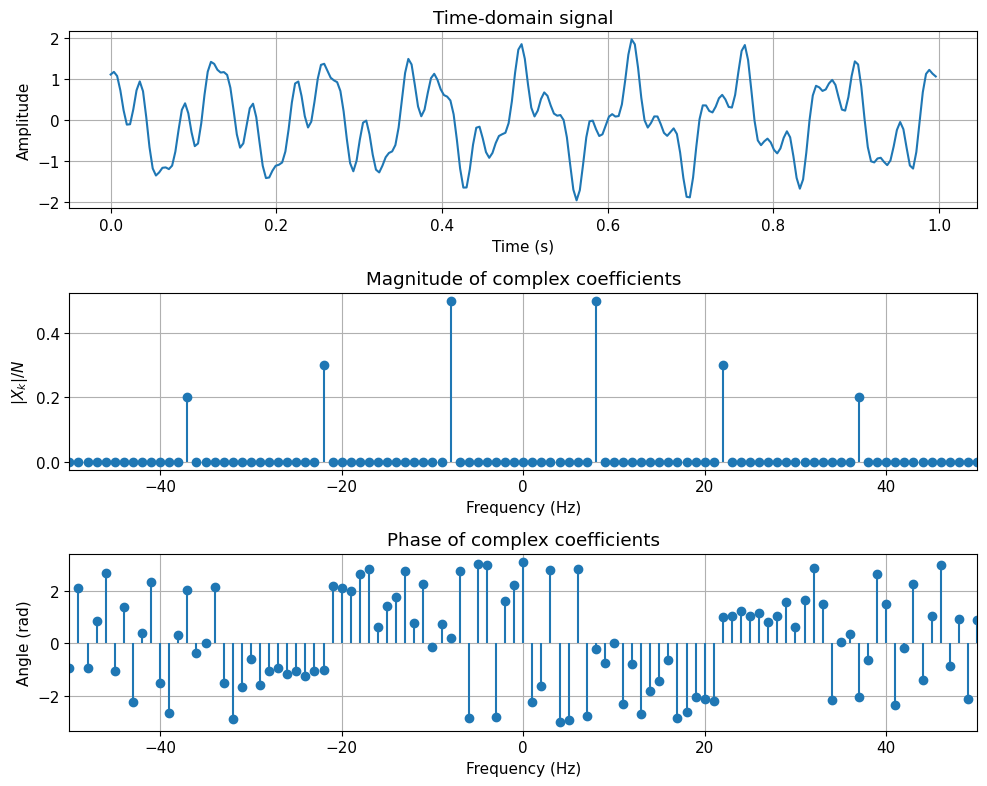

In [2]:
R = 256
T = 1.0
N = int(R*T)
t = np.arange(N)/R

x = (
    1.0*np.cos(2*np.pi*8*t - 0.2)
    + 0.6*np.cos(2*np.pi*22*t + 1.0)
    + 0.4*np.sin(2*np.pi*37*t - 0.5)
)

X = np.fft.fft(x)
freqs = np.fft.fftfreq(N, d=1/R)
X_shifted = np.fft.fftshift(X)
freqs_shifted = np.fft.fftshift(freqs)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
axs[0].plot(t, x)
axs[0].set_title("Time-domain signal")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude")
axs[1].stem(freqs_shifted, np.abs(X_shifted)/N, basefmt=" ")
axs[1].set_xlim(-50, 50)
axs[1].set_title("Magnitude of complex coefficients")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel(r"$|X_k|/N$")
axs[2].stem(freqs_shifted, np.angle(X_shifted), basefmt=" ")
axs[2].set_xlim(-50, 50)
axs[2].set_title("Phase of complex coefficients")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("Angle (rad)")
plt.tight_layout()
plt.show()

## Symmetry for real signals

For real-valued $x(t)$, the negative-frequency coefficient is the complex conjugate of the positive-frequency coefficient:

$$X_{-k} = X_k^*.$$

This is why real-valued signals do not need separate independent information at both $+f$ and $-f$.

In [3]:
errors = []
for k in range(1, N//2):
    errors.append(abs(X[-k] - np.conj(X[k])))
print("Largest conjugate-symmetry error:", max(errors))

for k in [8, 22, 37]:
    print(f"k={k:2d}: X[k]/N={X[k]/N:.4f}, X[-k]/N={X[-k]/N:.4f}, conj(X[k])/N={np.conj(X[k])/N:.4f}")

Largest conjugate-symmetry error: 1.464821375527116e-14
k= 8: X[k]/N=0.4900-0.0993j, X[-k]/N=0.4900+0.0993j, conj(X[k])/N=0.4900+0.0993j
k=22: X[k]/N=0.1621+0.2524j, X[-k]/N=0.1621-0.2524j, conj(X[k])/N=0.1621-0.2524j
k=37: X[k]/N=-0.0959-0.1755j, X[-k]/N=-0.0959+0.1755j, conj(X[k])/N=-0.0959+0.1755j


## Reconstruction from selected complex coefficients

If we keep a small number of coefficient pairs, the inverse FFT rebuilds the part of the signal represented by those frequencies.

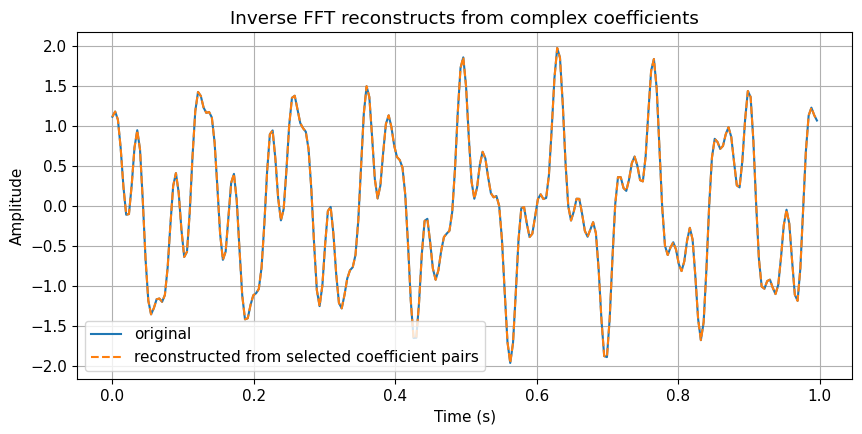

Max reconstruction error: 1.1934897514720433e-14


In [4]:
X_keep = np.zeros_like(X)
for k in [8, 22, 37]:
    X_keep[k] = X[k]
    X_keep[-k] = X[-k]

x_keep = np.fft.ifft(X_keep).real

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, x, label="original")
ax.plot(t, x_keep, "--", label="reconstructed from selected coefficient pairs")
ax.set_title("Inverse FFT reconstructs from complex coefficients")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()
print("Max reconstruction error:", np.max(np.abs(x - x_keep)))

## Fourier pair: rectangle and sinc

A rectangular pulse in one domain transforms into a sinc-shaped function in the conjugate domain. This pair reappears in diffraction from a slit.

With the convention

$$g(\nu)=\int f(t)e^{-i2\pi\nu t}\,dt,$$

a unit-width rectangle centered at zero has transform $\mathrm{sinc}(\nu)$, where NumPy's `np.sinc(x)` means $\sin(\pi x)/(\pi x)$.

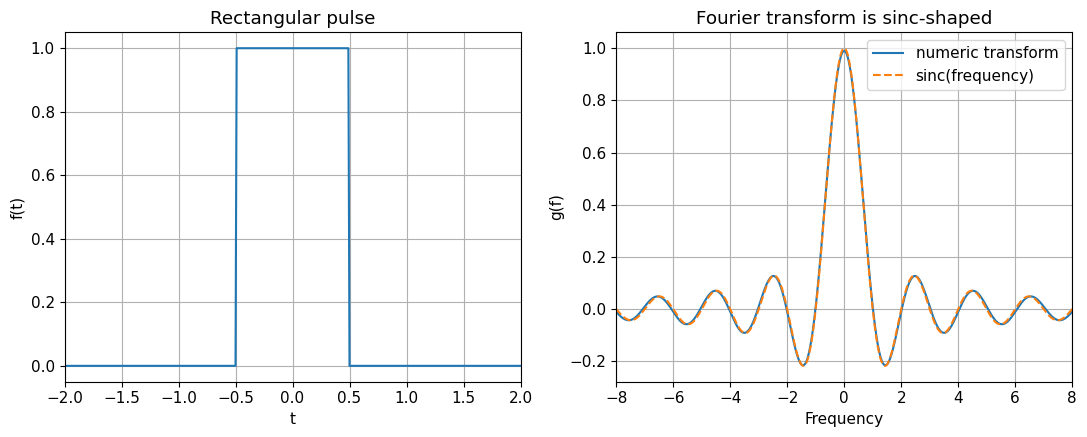

In [5]:
N = 4096
dt = 0.01
t = (np.arange(N) - N//2)*dt
rect = (np.abs(t) < 0.5).astype(float)

G = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rect))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, d=dt))

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].plot(t, rect)
axs[0].set_xlim(-2, 2)
axs[0].set_title("Rectangular pulse")
axs[0].set_xlabel("t")
axs[0].set_ylabel("f(t)")
axs[1].plot(freq, G.real, label="numeric transform")
axs[1].plot(freq, np.sinc(freq), "--", label="sinc(frequency)")
axs[1].set_xlim(-8, 8)
axs[1].set_title("Fourier transform is sinc-shaped")
axs[1].set_xlabel("Frequency")
axs[1].set_ylabel("g(f)")
axs[1].legend()
plt.tight_layout()
plt.show()

## Shift theorem: time shifts become phase ramps

Shifting a signal in time does not change its magnitude spectrum. It multiplies the transform by a complex phase factor.

For the $2\pi\nu$ convention:

$$f(t-t_0) \longleftrightarrow g(\nu)e^{-i2\pi\nu t_0}.$$

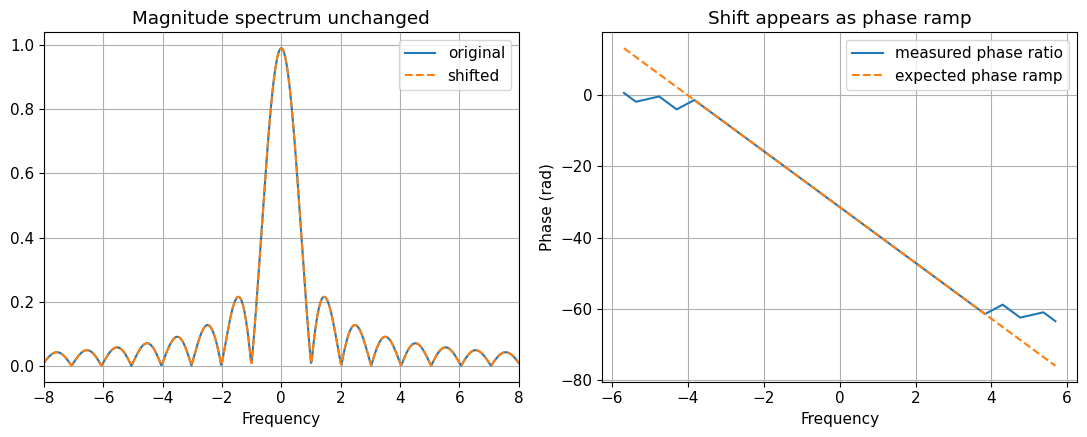

In [6]:
t0 = 1.25
rect_shifted = (np.abs(t - t0) < 0.5).astype(float)
G_shifted = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rect_shifted))) * dt

mask = (np.abs(G) > 0.05) & (np.abs(freq) < 8)
phase_ratio = np.unwrap(np.angle(G_shifted[mask] / G[mask]))
expected = -2*np.pi*freq[mask]*t0
# remove arbitrary 2pi offset by aligning medians
expected_aligned = expected + np.median(phase_ratio - expected)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].plot(freq, np.abs(G), label="original")
axs[0].plot(freq, np.abs(G_shifted), "--", label="shifted")
axs[0].set_xlim(-8, 8)
axs[0].set_title("Magnitude spectrum unchanged")
axs[0].set_xlabel("Frequency")
axs[0].legend()
axs[1].plot(freq[mask], phase_ratio, label="measured phase ratio")
axs[1].plot(freq[mask], expected_aligned, "--", label="expected phase ramp")
axs[1].set_title("Shift appears as phase ramp")
axs[1].set_xlabel("Frequency")
axs[1].set_ylabel("Phase (rad)")
axs[1].legend()
plt.tight_layout()
plt.show()

## Checkpoint

1. Shift the rectangle by a larger amount. What happens to the slope of the phase ramp?
2. Change the rectangle width. What happens to the sinc width?
3. Why can two signals have the same magnitude spectrum but different shapes?